IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# TD-TME07: les arbres de décision (catégoriel)

L'objectif de ce notebook est d'implémenter un algorithme d'apprentissage supervisé qui travaille sur des données catégorielles, l'algorithme de construction d'arbres de décision.


<font size="+1" color="RED"><b>[Q]</b></font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

PARANT Alexandre
Marc-Antoine XIA

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

Tout en haut de cette page, cliquer sur <tt>tme-07</tt> et rajouter à la suite de <tt>tme-07</tt> les noms des membres du binômes séparés par un tiret.

<font color="RED" size="+1">IMPORTANT: soumission de votre fichier final</font>

**Nom à donner au fichier à poster** : *tme-07-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme
- ne pas compresser ou faire une archive: il faut rendre le fichier ipython tel quel, éventuellement, si vous avez d'autres fichiers vous les rendez séparément.

**Echancier pour la soumission de votre compte-rendu:**
- le compte-rendu d'une séance doit être remis obligatoirement <font color="RED">avant la séance suivante</font>.

**Le compte-rendu est soumis sur la page Moodle.**

In [1]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
%matplotlib inline  

import math
import time
import sys

# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2

# - - - - - - - - - - - - - - - - - -
# Information sur l'environnent utilisé ici:
print("Version python et des librairies:")
print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

Version python et des librairies:
	Python  3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]
	pandas:  2.2.0
	numpy:  1.24.2
	matplotlib:  3.6.3


/tmp/ipykernel_17741/1189054792.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
import sys
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev



In [3]:
# Chargement des fichiers de données :

elections_df = pd.read_csv("data/elections.csv")
elections_df

,Adresse,Majeur?,Nationalite,Label
0,Paris,oui,Francais,1
1,Paris,non,Francais,-1
2,Montpellier,oui,Italien,1
3,Paris,oui,Suisse,-1
4,Strasbourg,non,Italien,-1
5,Strasbourg,non,Francais,-1
6,Strasbourg,oui,Francais,1
7,Montpellier,oui,Suisse,-1


In [4]:
# Pour ne garder que le nom des variables de description (et pas la classe):
# sous la forme d'une liste:

elections_noms = [nom for nom in elections_df.columns if nom != 'Label']

# Passer du dataframe à des arrays:
elections_desc = np.array(elections_df[elections_noms])
elections_label = np.array(elections_df['Label'])

print("Noms des features: ",elections_noms)

Noms des features:  ['Adresse', 'Majeur?', 'Nationalite']


In [5]:
elections_label[elections_desc[:,0] == "Paris"]

array([ 1, -1, -1])

## Premières fonctions: entropie et classe majoritaire

<font color="RED" size="+1">**[Q]**</font> Ecrire la fonction <code>classe_majoritaire</code> qui, étant donné un array de labels rend la classe majoritaire (celle qui est possédée par le plus grand nombre d'exemples donc...). En cas d'égalité, cette fonction rend la première classe rencontrée.

**indication :** utiliser la fonction numpy `unique`.

In [6]:
def classe_majoritaire(Y):
    """ Y : (array) : array de labels
        rend la classe majoritaire ()
    """
    #### A compléter pour répondre à la question posée
    classes, nb = np.unique(Y, return_counts=True)
    return classes[np.argmax(nb)]


In [7]:
#Vérification sur nos données:
classe_majoritaire(elections_label)


-1

### Entropie et gain d'information

<div class="alert alert-block alert-warning">
    
On note $\{c_1, c_2,..., c_k\}$, l'ensemble des valeurs de classes possibles dans un ensemble $Y$.

On note $p_1$ la probabilité de la classe $c_1$ parmi $Y$, etc., et on note $P=(p_1, p_2,..., p_k)$ la distribution de probabilités sur les classes (on a $\sum_{i=1}^{k} p_i =1$ et $p_i \in [0,1]$ pour tout $i$).

L'**entropie de Shannon** de la distribution $P$ est donnée par:

$ H_S(P) = -\sum_{i=1}^{k} p_i \log_k(p_i)$
</div>

Pour ce qui suit, une *distribution de probabilités* est représentée par une **liste** Python $P=[p_1,...,p_k]$ de valeurs réelles telle que
* pour tout $i=1,..., k$ : $0 \leq p_i \leq 1$
* $\sum_{i=1}^{k}p_i = 1$

Dans le calcul de l'entropie, la base du $\log$ à utiliser est $k$, donc le nombre de valeurs dans la liste $P$. 

<font color="RED" size="+1">**[Q]**</font> 
Ecrire la fonction `shannon` qui, étant donné une distribution de probabilités $P$ rend la valeur de $H_S(P)$, l'entropie de Shannon de la distribution associée à $P$. Pour les besoins d'implémentation de l'algorithme de construction d'arbres, ajouter à la fonction un deuxième argument qui donne la base $k$ du logarithme à utiliser (par défaut, cet argument a la valeur 2). On fera l'hypothèse que $k$ est positif et non nul.

**Remarques :** utiliser la fonction **log2* de la librairie `numpy` qui permet de calculer le logarithme en base 2.


In [8]:
def shannon(P,k=2):
    """ list[Number] * int -> float
        Hypothèse: P est une distribution de probabilités et k>0
        - P: distribution de probabilités
        - k: base du logarithme à utiliser, par défaut 2
        rend la valeur de l'entropie de Shannon correspondante
    """
    ########################## COMPLETER ICI 
    P = np.array(P)
    if k != 0 and k != 1:
        return -np.sum(P[P != 0] * np.log(P[P != 0]) / np.log(k) )
    return 0.0
    # return -np.sum(P[P != 0] * np.log2(P[P != 0]) )
    
    ##########################
    

In [9]:
# Exemples d'utilisation:
print("\nH([1]) = ", shannon([1]))                                                  # calcul du log en base 2
print("\nH([0, 1, 0],3) = ", shannon([0, 1, 0],3))                                  # calcul du log en base 3

print("\nH([0.25, 0.25, 0.25, 0.25], 4) = ", shannon([0.25, 0.25, 0.25, 0.25], 4))  # calcul du log en base 4
print("\nH([0.25, 0.25, 0.25, 0.25]) = ", shannon([0.25, 0.25, 0.25, 0.25]))        # calcul du log en base 2

print("\nH([0.7, 0, 0.1, 0.2, 0], 5) = ", shannon([0.7, 0, 0.1, 0.2, 0], 5))        # calcul du log en base 5
print("\nH([0.7, 0, 0.1, 0.2, 0]) = ", shannon([0.7, 0, 0.1, 0.2, 0]))              # calcul du log en base 2

print("\nH([1/3, 2/3]) = ", shannon([1/3, 2/3]))                                    # calcul du log en base 2
print("\nH([1/3, 2/3, 0], 3) = ", shannon([1/3, 2/3, 0], 3))                        # calcul du log en base 3
print("\nH([1/3, 2/3, 0]) = ", shannon([1/3, 2/3, 0]))                              # calcul du log en base 2

print("\nH([1/3, 1/3, 1/3], 3) = ", shannon([1/3, 1/3, 1/3], 3))                    # calcul du log en base 3
print("\nH([1/3, 1/3, 1/3]) = ", shannon([1/3, 1/3, 1/3]))                          # calcul du log en base 2




H([1]) =  -0.0

H([0, 1, 0],3) =  -0.0

H([0.25, 0.25, 0.25, 0.25], 4) =  1.0

H([0.25, 0.25, 0.25, 0.25]) =  2.0

H([0.7, 0, 0.1, 0.2, 0], 5) =  0.4981978778731972

H([0.7, 0, 0.1, 0.2, 0]) =  1.1567796494470395

H([1/3, 2/3]) =  0.9182958340544896

H([1/3, 2/3, 0], 3) =  0.579380164285695

H([1/3, 2/3, 0]) =  0.9182958340544896

H([1/3, 1/3, 1/3], 3) =  1.0

H([1/3, 1/3, 1/3]) =  1.584962500721156


<font color="RED" size="+1">**[Q]**</font> Tracer, à l'aide de la fonction `plot`, la courbe donnant la valeur de `shannon([p, 1-p])` en fonction de `p`.

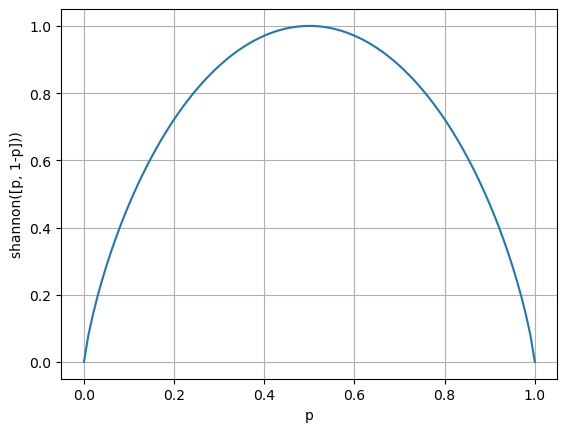

In [10]:
# Tracé de la courbe:

X = np.arange(0, 1+0.01, 0.01)
Y = np.array([shannon([p, 1-p]) for p in X])

plt.xlabel("p")
plt.ylabel("shannon([p, 1-p]))")
plt.grid()
plt.plot(X, Y)


<font color="RED" size="+1">**[Q]**</font> A l'aide de la fonction <code>shannon</code>, écrire la fonction <code>entropie</code> qui prend un ensemble de labels en argument et renvoie l'entropie de la distribution des classes dans cet ensemble. Pour les besoins d'implémentation de l'algorithme de construction d'arbres, ajouter à la fonction un deuxième argument qui donne la base $k$ du logarithme à utiliser pour la fonction `shannon` (par défaut, cet argument a la valeur 2). On fera l'hypothèse que $k$ est positif et non nul.

In [11]:
def entropie(Y, k=2):
    """ Y : (array) : ensemble de labels de classe
        Hypothèse: k>0
        - k: base du logarithme à utiliser, par défaut 2
        rend l'entropie de l'ensemble Y
    """
    ########################## COMPLETER ICI 
    classes, nb = np.unique(Y, return_counts=True)
    nbTot = np.sum(nb)
    probas = nb / nbTot

    k = len(nb)
    return shannon(probas, k)

    ##########################
    

In [12]:
np.random.seed(42)

# Exemple sur nos données :
print(f"Entropie de {elections_label} : {entropie(elections_label):1.4f}")

exemple = np.random.randint(2, size=35)
print(f"Entropie de {exemple} (base 2): {entropie(exemple):1.4f}")

exemple = np.random.randint(3, size=35)
print(f"Entropie de {exemple} (base 3): {entropie(exemple,3):1.4f}")

exemple = np.random.randint(7, size=35)
print(f"Entropie de {exemple} (base 7): {entropie(exemple,7):1.4f}")

Entropie de [ 1 -1  1 -1 -1 -1  1 -1] : 0.9544
Entropie de [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1] (base 2): 0.9947
Entropie de [0 0 0 2 2 2 1 2 1 1 2 1 2 2 0 2 0 2 2 0 0 2 1 0 1 1 1 0 1 0 1 2 2 0 2] (base 3): 0.9905
Entropie de [2 5 0 3 1 3 1 5 5 5 1 3 5 4 6 1 1 3 1 1 5 3 5 6 6 5 6 3 0 5 4 4 1 6 4] (base 7): 0.9147


## Arbres de décision

Dans cette partie, on réalise l'implémentation de l'algorithme de construction d'un arbre de décision.

### Représentation d'un arbre en Python

<div class="alert alert-block alert-warning">
Pour représenter un arbre en Python, on a besoin de définir une structure de données adéquate. 

Un arbre de décision est défini par des **noeuds** qui sont de 2 types :
- *noeud interne* : c'est un noeud qui est associé à un attribut (ie. une feature de description des exemples) et qui possède des fils qui sont aussi des noeuds. 
- *feuille* : c'est un noeud qui est associé à un label de la classe et qui a la particularité de ne pas avoir de descendants.
</div>

Pour représenter des noeuds, nous définissons la classe `NoeudCategoriel` suivante:

In [146]:
# La librairie suivante est nécessaire pour l'affichage graphique de l'arbre:
import graphviz as gv

class NoeudCategoriel:
    """ Classe pour représenter des noeuds d'un arbre de décision
    """
    def __init__(self, num_att=-1, nom=''):
        """ Constructeur: il prend en argument
            - num_att (int) : le numéro de l'attribut auquel il se rapporte: de 0 à ...
              si le noeud se rapporte à la classe, le numéro est -1, on n'a pas besoin
              de le préciser
            - nom (str) : une chaîne de caractères donnant le nom de l'attribut si
              il est connu (sinon, on ne met rien et le nom sera donné de façon 
              générique: "att_Numéro")
        """
        self.__attribut = num_att    # numéro de l'attribut
        if (nom == ''):            # son nom si connu
            self.__nom_attribut = 'att_'+str(num_att)
        else:
            self.__nom_attribut = nom 
        self.__Les_fils = None       # aucun fils à la création, ils seront ajoutés
        self.__classe   = None       # valeur de la classe si c'est une feuille

    def getattribut(self):
        return self.__attribut
        
    def est_feuille(self):
        """ rend True si l'arbre est une feuille 
            c'est une feuille s'il n'a aucun fils
        """
        return self.__Les_fils == None
    
    def ajoute_fils(self, valeur, Fils):
        """ valeur : valeur de l'attribut de ce noeud qui doit être associée à Fils
                     le type de cette valeur dépend de la base
            Fils (NoeudCategoriel) : un nouveau fils pour ce noeud
            Les fils sont stockés sous la forme d'un dictionnaire:
            Dictionnaire {valeur_attribut : NoeudCategoriel}
        """
        if self.__Les_fils == None:
            self.__Les_fils = dict()
        self.__Les_fils[valeur] = Fils
        # Rem: attention, on ne fait aucun contrôle, la nouvelle association peut
        # écraser une association existante.
    
    def ajoute_feuille(self,classe):
        """ classe: valeur de la classe
            Ce noeud devient un noeud feuille
        """
        self.__classe    = classe
        self.__Les_fils  = None   # normalement, pas obligatoire ici, c'est pour être sûr
        
    def classifie(self, exemple):
        """ exemple : numpy.array
            rend la classe de l'exemple 
            on rend la valeur None si l'exemple ne peut pas être classé (cf. les questions
            posées en fin de ce notebook)
        """
        if self.est_feuille():
            return self.__classe
        if exemple[self.__attribut] in self.__Les_fils:
            # descente récursive dans le noeud associé à la valeur de l'attribut
            # pour cet exemple:
            return self.__Les_fils[exemple[self.__attribut]].classifie(exemple)
        else:
            # Cas particulier : on ne trouve pas la valeur de l'exemple dans la liste des
            # fils du noeud... Voir la fin de ce notebook pour essayer de résoudre ce mystère...
            print('\t*** Warning: attribut ',self.__nom_attribut,' -> Valeur inconnue: ',exemple[self.__attribut])
            return None
    
    def compte_feuilles(self):
        """ rend le nombre de feuilles sous ce noeud
        """
        if self.est_feuille():
            return 1
        total = 0
        for noeud in self.__Les_fils:
            total += self.__Les_fils[noeud].compte_feuilles()
        return total
     
    def to_graph(self, g, prefixe='A'):
        """ construit une représentation de l'arbre pour pouvoir l'afficher graphiquement
            Cette fonction ne nous intéressera pas plus que ça, elle ne sera donc pas expliquée            
        """
        if self.est_feuille():
            g.node(prefixe,str(self.__classe),shape='box')
        else:
            g.node(prefixe, self.__nom_attribut)
            i =0
            for (valeur, sous_arbre) in self.__Les_fils.items():
                sous_arbre.to_graph(g,prefixe+str(i))
                g.edge(prefixe,prefixe+str(i), str(valeur))
                i = i+1        
        return g


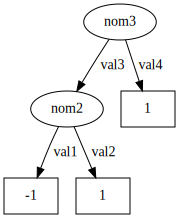

In [14]:
# Exemple d'utilisation: 
un_noeud0= NoeudCategoriel() 
un_noeud0.ajoute_feuille(-1)

un_noeud1= NoeudCategoriel()
un_noeud1.ajoute_feuille(+1)

un_noeud2= NoeudCategoriel(42,"nom2")
un_noeud2.ajoute_fils("val1",un_noeud0)
un_noeud2.ajoute_fils("val2",un_noeud1)

un_noeud3 = NoeudCategoriel(11,"nom3")
un_noeud3.ajoute_fils("val3",un_noeud2)

un_noeud4= NoeudCategoriel() 
un_noeud4.ajoute_feuille(1)
un_noeud3.ajoute_fils("val4",un_noeud4)

# L'affichage se fait en 2 temps
# 1) on initialise un graphe orienté :
gtree = gv.Digraph(format='png')
# 2) on le rempli en appelant la méthode de la classe NoeudCategoriel
un_noeud3.to_graph(gtree)

### Construction de l'arbre de décision

<div class="alert alert-block alert-warning">
Comme on l'a vu dans le cours, pour construire un arbre de décision à partir d'un dataset ($X$, $Y$), il faut réaliser les étapes suivantes:
    
1. calculer l'entropie de Shannon de l'ensemble des classes $Y$, on la note $H_S(Y)$.
    
2. si $H_S(Y)$ est inférieure à epsilon (qui est un réel positif donné en paramètre de l'algorithme), alors construire une feuille avec cet ensemble, la classe associée à cette feuille est la classe majoritaire dans $Y$.
    
3. sinon, pour chaque attribut $X_j$ qui décrit les exemples de $X$,
    
    3.1. pour chacune des valeurs $v_{jl}$ de $X_j$ construire l'ensemble des exemples de $X$ qui possède la valeur $v_{jl}$ ainsi que l'ensemble de leurs labels.
    
    3.2. calculer l'entropie conditionnelle de Shannon de la classe relativement à l'attribut $X_j$. On note $H_S(Y|X_j)$ cette entropie    
    
4. l'attribut $X_{best}$ qui **maximise le gain d'information** est choisi pour constituer un nouveau noeud $\eta$ de l'arbre de décision:
    
    4.1. chaque valeur de $X_{best}$ est utilisée pour décomposer ($X$, $Y$) en autant de datasets que $X_{best}$ possède de valeurs: chaque dataset est séparant $X$ et $Y$ selon la valeur prise pour $X_{best}$. 
    
    4.2. pour chaque dataset obtenu on reprend en 1 pour construire chacun des fils de $\eta$. 


On rappelle que le gain d'information est:

$$I_S(X_j,Y) = H_S(Y) - H_S(Y|X_j)$$

**Remarques**: 

- si le gain d'information est nul pour tous les attributs, alors on arrête la décomposition et on construit une feuille avec cet ensemble en donnant la classe majoritaire comme étiquette à cette feuille.
- pour la construction d'un arbre de décision, on utilise toujours le $\log$ en base $2$ pour le calcul des entropies.

</div>

<font color="RED" size="+1">**[Q]**</font> Compléter la fonction `construit_AD`suivante afin qu'elle permette de construire un arbre de décision. Cette fonction rend un `NoeudCategoriel` qui correspond à l'arbre construit pour le dataset $(X,Y)$ donné.

In [69]:
def construit_AD(X,Y,epsilon,LNoms = [], verbose=False):
    """ X,Y : dataset
        epsilon : seuil d'entropie pour le critère d'arrêt 
        LNoms : liste des noms de features (colonnes) de description 
    """
    
    entropie_ens = entropie(Y)
    if verbose:
        print(f"Construction: entropie classe {entropie_ens:1.5f}")
    if (entropie_ens <= epsilon):
        # ARRET : on crée une feuille
        noeud = NoeudCategoriel(-1,"Label")
        noeud.ajoute_feuille(classe_majoritaire(Y))
        if verbose:
            print(f"\tajout d'une feuille avec la classe {classe_majoritaire(Y)}")
    else:
        min_entropie = 1.1
        i_best = -1
        Xbest_valeurs = None
        
        ############
    
        for attribut in range(X.shape[1]):
            notreColonne = X[:, attribut]
            vj, nb_x = np.unique(notreColonne, return_counts=True)

            newEntropy = 0.0
            for ivjl in range(len(vj)):
                vjl = vj[ivjl]
                Y_ = Y[notreColonne == vjl]
                newEntropy += entropie(Y_) * (nb_x[ivjl] / len(Y))

            if newEntropy < min_entropie:
                min_entropie = newEntropy
                i_best = attribut
                Xbest_valeurs = vj
        
        # COMPLETER CETTE PARTIE : ELLE DOIT PERMETTRE D'OBTENIR DANS
        # i_best : le numéro de l'attribut qui minimise l'entropie
        # min_entropie : la valeur de l'entropie minimale
        # Xbest_valeurs : la liste des valeurs que peut prendre l'attribut i_best
        #
        # Il est donc nécessaire ici de parcourir tous les attributs et de calculer
        # la valeur de l'entropie de la classe pour chaque attribut.
        
        
         
        #############################################
        if verbose:
            nom = str(i_best)
            if LNoms != []:
                nom = LNoms[i_best]
            print(f"\tMeilleur: {nom}: entropie= {min_entropie:1.5f}")
        if len(LNoms)>0:  # si on a des noms de features
            noeud = NoeudCategoriel(i_best,LNoms[i_best])    
        else:
            noeud = NoeudCategoriel(i_best)
        for v in Xbest_valeurs:
            if verbose:
                print(f"\tdescente pour {v}")
            noeud.ajoute_fils(v,construit_AD(X[X[:,i_best]==v], Y[X[:,i_best]==v],epsilon,LNoms,verbose))
    return noeud

La classe pour implémenter un arbre de décision dérive de la classe `Classifier`. Elle utilise la fonction `construit_AD` dans sa méthode `train` pour construire un arbre à partir d'un dataset donné.

<font color="RED" size="+1">**[Q]**</font> Compléter la classe suivante en donnant le code des méthodes `train` et `predict`.

**Remarque :** la méthode `score` ne fera rien dans notre cas, on verra dans un autre notebook comment on pourrait la définir.

In [125]:
class ClassifierArbreDecision(cl.Classifier):
    """ Classe pour représenter un classifieur par arbre de décision
    """
    
    def __init__(self, input_dimension, epsilon, LNoms=[]):
        """ Constructeur
            Argument:
                - intput_dimension (int) : dimension de la description des exemples
                - epsilon (float) : paramètre de l'algorithme (cf. explications précédentes)
                - LNoms : Liste des noms de dimensions (si connues)
            Hypothèse : input_dimension > 0
        """
        super().__init__(input_dimension)  # Appel du constructeur de la classe mère
        self.__epsilon = epsilon
        self.__LNoms = LNoms
        # l'arbre est manipulé par sa racine qui sera un Noeud
        self.__racine = None
        
    def __str__(self):
        """  -> str
            rend une chaîne de caractères (méthode toString) avec le nom du classifieur avec ses paramètres
        """
        return  super().__str__()+' - ArbreDecision ['+str(super().get_dimension()) + '] eps='+str(self.__epsilon)
        
    def train(self, desc_set, label_set,verbose=False):
        """ Permet d'entrainer le modele sur l'ensemble donné
            desc_set: ndarray avec des descriptions
            label_set: ndarray avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """        
        #def construit_AD(X,Y,epsilon,LNoms = [], verbose=False):

        self.__racine = construit_AD(desc_set, label_set, self.__epsilon, self.__LNoms, verbose)
    
        ##################
        ## COMPLETER ICI !
        ##################
    
    def score(self,x):
        """ rend le score de prédiction sur x (valeur réelle)
            x: une description
        """
        # cette méthode ne fait rien dans notre implémentation :
        pass
    
    def predict(self, x):
        """ x (array): une description d'exemple
            rend la prediction sur x             
        """

        currentRoot = self.__racine
        while currentRoot.est_feuille() == False:
            num_att = currentRoot._NoeudCategoriel__attribut
            if x[num_att] not in currentRoot._NoeudCategoriel__Les_fils:
                return None
            currentRoot = currentRoot._NoeudCategoriel__Les_fils[x[num_att]]

        return currentRoot._NoeudCategoriel__classe


    def accuracy(self, desc_set, label_set):
        """ Permet de calculer la qualité du système sur un dataset donné
            desc_set: ndarray avec des descriptions
            label_set: ndarray avec les labels correspondants
            Hypothèse: desc_set et label_set ont le même nombre de lignes
        """
        return np.mean(label_set==np.apply_along_axis(self.predict, 1, desc_set))

    
    def number_leaves(self):
        """ rend le nombre de feuilles de l'arbre
        """
        return self.__racine.compte_feuilles()
    
    def draw(self,GTree):
        """ affichage de l'arbre sous forme graphique
            Cette fonction modifie GTree par effet de bord
        """
        self.__racine.to_graph(GTree)

### Premières expérimentations

Apprentissage d'un arbre de décision avec la base sur les élections :

Construction: entropie classe 0.95443
	Meilleur: Majeur?: entropie= 0.60684
	descente pour non
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe -1
	descente pour oui
Construction: entropie classe 0.97095
	Meilleur: Nationalite: entropie= 0.00000
	descente pour Francais
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe 1
	descente pour Italien
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe 1
	descente pour Suisse
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe -1

------
Arbre construit pour Classifier #35 (d3) - ArbreDecision [3] eps=0.0:


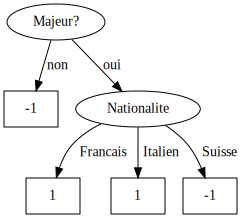

In [126]:
# Initialiation d'un arbre pour le dataset Elections:
arbre_elections = ClassifierArbreDecision(len(elections_noms), 0.0, elections_noms)

# Construction de l'arbre de décision à partir du dataset Elections
arbre_elections.train(elections_desc,elections_label,verbose=True)

# Construction de la représentation graphique (affichage)
graphe_arbre_elections = gv.Digraph(format='png')
arbre_elections.draw(graphe_arbre_elections)

# Affichage du graphe obtenu:
print(f"\n------\nArbre construit pour {arbre_elections}:")
graphe_arbre_elections

Pour classer un nouvel exemple avec un arbre de décision, on utilise la méthode <code>predict</code> qui utilise la méthode `classifie` de la classe `NoeudCategoriel` pour classer un nouvel exemple et renvoyer le label +1 ou -1 selon le cas. 

Exemple de classification d'un exemple avec l'arbre obtenu :

In [127]:
arbre_elections.predict(elections_desc[0,:])

1

Classification d'un nouvel exemple qui n'appartient à pas au dataset d'apprentissage :

In [128]:
# Rappel : elections_noms = ['Adresse', 'Majeur?', 'Nationalite']
arbre_elections.predict(np.array(['Paris','oui','Italien']))

1

Mesure de l'accuracy de l'arbre obtenu :

In [129]:
arbre_elections.accuracy(elections_desc,elections_label)

1.0

## Première expérimentation avec la base Mushrooms

Pour mieux évaluer notre nouvel algortithme d'apprentissage, on va utiliser la base des champignons `mushrooms-1000.csv` qui est fournie dans le répertoire `data`. Ce dataset est une version réduite du dataset original qui comporte plus de 8000 champignons.



Dans le répertorie `data/` fourni avec ce sujet, vous pouvez trouver 6 fichiers `mushrooms-****.csv`. Ces 6 fichiers ont été obtenus en partitionant le fichier orignal `mushrooms.csv` que l'on peut trouver sur internet. Dans cette base originale, il y a 8124 champignons recensés. Ce fichier original a été découpé en 5 fichiers de 1400 champignons et 1 fichier de 1124 champignons. L'union de ces 6 fichiers permet donc de recomposer le fichier original.


### Construction d'un arbre de décision

Dans un premier temps, on vérifie que notre algorithme d'apprentissage fonctionne correctement en construisant un arbre de décision à partir d'un des fichiers.

On commence par charger le fichier dans un dataframe et on le transforme en dataset (cf. le notebook précédent pour le détail des étapes):

In [130]:
# Chargement des fichiers de données sur les mushrooms:

# On commence par travailler sur un des fichier "mushrooms-1400"
mushrooms_df = pd.read_csv("data/mushrooms-1400-1.csv")

mushrooms_df


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,y,n,f,y,f,c,n,b,...,s,p,w,p,w,o,e,w,v,d
1,p,x,s,n,f,y,f,c,n,b,...,k,p,w,p,w,o,e,w,v,l
2,p,x,f,y,f,f,f,c,b,g,...,k,b,p,p,w,o,l,h,v,d
3,p,x,f,y,f,f,f,c,b,g,...,k,n,b,p,w,o,l,h,y,g
4,p,x,f,y,f,f,f,c,b,h,...,k,p,b,p,w,o,l,h,y,d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395,p,x,y,e,f,f,f,c,n,b,...,k,w,w,p,w,o,e,w,v,p
1396,e,f,y,n,t,n,f,c,b,p,...,s,w,g,p,w,o,p,k,v,d
1397,e,f,f,e,t,n,f,c,b,n,...,s,p,g,p,w,o,p,n,y,d
1398,p,x,f,y,f,f,f,c,b,p,...,k,n,b,p,w,o,l,h,y,d


In [131]:
# Dans ce dataframe, la colonne de classe s'appelle 'class'
mushrooms_noms = [nom for nom in mushrooms_df.columns if nom != 'class']

# Passer du dataframe à un dataset (2 arrays desc & labels):
mushrooms_1_desc = np.array(mushrooms_df[mushrooms_noms])
mushrooms_1_label = np.array(mushrooms_df['class'])


Ensuite, on construit l'arbre de décision correspondant.

<font color="RED" size="+1">**[Q]**</font> Compléter le code suivant pour apprendre l'arbre et l'afficher ensuite:

Construction: entropie classe 0.99554
	Meilleur: odor: entropie= 0.07290
	descente pour a
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe e
	descente pour c
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p
	descente pour f
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p
	descente pour l
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe e
	descente pour m
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p
	descente pour n
Construction: entropie classe 0.16355
	Meilleur: spore-print-color: entropie= 0.04006
	descente pour b
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe e
	descente pour h
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe e
	descente pour k
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe e
	descente pour n
Construction: entropie classe 0.00000
	ajout d'une feuille avec

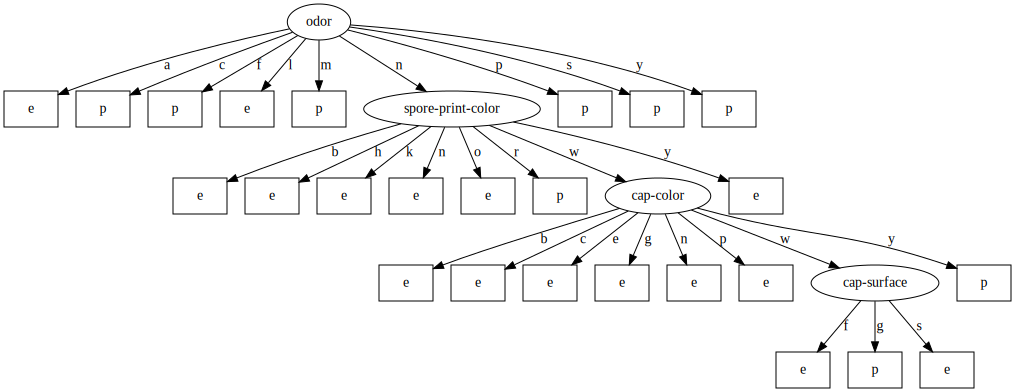

In [132]:
# construction de l'arbre de décision à partir du dataset Elections:
arbre_mushrooms_1 = ClassifierArbreDecision(len(mushrooms_noms), 0.0, mushrooms_noms)

# Affichage du graphe obtenu:
arbre_mushrooms_1.train(mushrooms_1_desc, mushrooms_1_label, True)

# L'affichage se fait en 2 temps
# 1) on initialise un graphe orienté :
gtree = gv.Digraph(format='png')
arbre_mushrooms_1.draw(gtree)
gtree

### Classification avec l'arbre de décision obtenu

Exemple de classification d'un exemple:

In [133]:
arbre_mushrooms_1.predict(mushrooms_1_desc[0,:])

'p'

Calcul de l'accuracy sur le dataset d'apprentissage.

**Attention**: la fonction `accuracy` doit pouvoir tenir compte du fait que les classes ne sont pas égales à +1 ou -1 comme c'était le cas avec les datasets utilisés jusqu'à présent.


In [134]:
arbre_mushrooms_1.accuracy(mushrooms_1_desc,mushrooms_1_label)

1.0

<font color="RED" size="+1">**[Q]**</font> Toujours avec le dataset `mushrooms_1` précédent, construire un nouvel arbre de décision en utilisant comme valeur d'epsilon : $0.25$.

Que constatez-vous ? 

Construction: entropie classe 0.99554
	Meilleur: odor: entropie= 0.07290
	descente pour a
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe e
	descente pour c
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p
	descente pour f
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p
	descente pour l
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe e
	descente pour m
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p
	descente pour n
Construction: entropie classe 0.16355
	ajout d'une feuille avec la classe e
	descente pour p
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p
	descente pour s
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p
	descente pour y
Construction: entropie classe 0.00000
	ajout d'une feuille avec la classe p


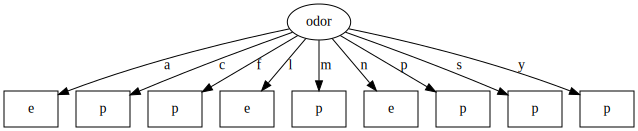

In [135]:
# construction de l'arbre de décision à partir du dataset Elections:
arbre_mushrooms_1_bis = ClassifierArbreDecision(len(mushrooms_noms), 0.25, mushrooms_noms)

# Affichage du graphe obtenu:
arbre_mushrooms_1_bis.train(mushrooms_1_desc, mushrooms_1_label, True)

# L'affichage se fait en 2 temps
# 1) on initialise un graphe orienté :
gr_arbre_mushrooms_1_bis = gv.Digraph(format='png')
arbre_mushrooms_1_bis.draw(gr_arbre_mushrooms_1_bis)


# Affichage du graphe obtenu:
gr_arbre_mushrooms_1_bis

<font color="RED" size="+1">**[Q]**</font> Déterminer l'accuracy de ce nouvel arbre.


In [136]:
arbre_mushrooms_1_bis.accuracy(mushrooms_1_desc,mushrooms_1_label)

0.9892857142857143

<font color="RED" size="+1">**[Q]**</font> D'après ces résultats, de ces 2 arbres, quel est celui qui a sur-appris ? 

In [137]:
# Le premier car il y a une précision de 100%

<font color="RED" size="+1">**[Q]**</font> La complexité d'un arbre est généralement évaluée en comptant le nombre de ses feuilles. Dans la classe `ClassifierArbreDecision` la méthode `number_leaves()` doit rendre le nombre de feuilles de l'arbre en question. Cette méthode appelle la méthode `nombre_feuilles()` de la classe `NoeudCategoriel` qui vous est fournie sans son code. Compléter la définition de `nombre_feuilles()` dans la classe `NoeudCategoriel` afin de pouvoir compter les feuilles de l'arbre.


In [138]:
print("Nombre de feuilles de l'arbre: ",arbre_mushrooms_1_bis.number_leaves())

Nombre de feuilles de l'arbre:  9


In [139]:
print("Nombre de feuilles de l'arbre: ",arbre_mushrooms_1.number_leaves())

Nombre de feuilles de l'arbre:  25


## Plus d'expérimentations avec la base Mushrooms

On décide maintenant d'évaluer plus en détail ce nouvel algorithme. On souhaite:
1. construire un arbre avec chaque fichier `mushrooms-1400-*.csv` 
2. pour chaque arbre construit, évaluer son accuracy:
    - sur le dataset d'apprentissage
    - sur les 4 autres fichiers `mushrooms-1400-*.csv`
    - sur le fichier `mushrooms-1124.csv`
    
    
**Remarque :** normalement, tous ces tests devraient pouvoir se faire dans un temps raisonnable, dans le cas contraire, faites les un par un.

In [140]:
# Chargement des fichiers mushrooms et apprentissage
mushrooms_desc = []
mushrooms_label = []
arbres_mushrooms = []
for j in range(0,5):
    mushrooms_df = pd.read_csv("data/mushrooms-1400-"+str(j+1)+".csv")
    mushrooms_noms = [nom for nom in mushrooms_df.columns if nom != 'class']
    # Passer du dataframe à un dataset (2 arrays):
    mushrooms_desc.append(np.array(mushrooms_df[mushrooms_noms]))
    mushrooms_label.append(np.array(mushrooms_df['class']))
    
    # Apprentissage
    arbres_mushrooms.append(ClassifierArbreDecision(len(mushrooms_noms), 0.0, mushrooms_noms))
    arbres_mushrooms[j].train(mushrooms_desc[j],mushrooms_label[j])

In [141]:
# Fichier qui va nous servir à tester
mushrooms_df = pd.read_csv("data/mushrooms-1124.csv")

# Passer du dataframe à un dataset (2 arrays):
mushrooms_test_desc = np.array(mushrooms_df[mushrooms_noms])
mushrooms_test_label = np.array(mushrooms_df['class'])

<font color="RED" size="+1">**[Q]**</font> Donner les instructions permettant d'obtenir le taux de bonne classification (accuracy) de chacun des arbres construits sur les autres bases, sur le modèle suivant:

In [142]:
for j in range(0,5):
    print(j, arbres_mushrooms[j].accuracy(mushrooms_test_desc,mushrooms_test_label))

0 0.9955516014234875
1 0.994661921708185
2 1.0
3 1.0
4 0.99644128113879


<font color="RED" size="+1">**[Q]**</font> On peut remarquer que pour certains arbres, la classification de certains exemples produit un warning.
En étudiant les exemples suivant et leur classification par le premier arbre, expliquez pourquoi un warning se produit.
Est-ce normal ? Pourrait-on trouver une solution pour ces cas-là ?


In [ ]:
# Je n'ai pas de warning

<font color="RED" size="+1">**[Q]**</font> Réaliser une validation croisée en 10 paquets sur la base mushrooms_1, puis sur la base mushrooms complète.

In [145]:

mushrooms_1_df = pd.read_csv("data/mushrooms-1400-1.csv")

# Dans ce dataframe, la colonne de classe s'appelle 'class'
mushrooms_1_noms = [nom for nom in mushrooms_1_df.columns if nom != 'class']

# Passer du dataframe à un dataset (2 arrays desc & labels):
mushrooms_1_desc = np.array(mushrooms_1_df[mushrooms_1_noms])
mushrooms_1_label = np.array(mushrooms_1_df['class'])

###################### A COMPLETER 

arbre = ClassifierArbreDecision(len(mushrooms_1_noms), 0.0, mushrooms_1_noms)


# Remarque: j'ai mis des affichage dans la fonction validation croisée afin de montrer
# ce qui se passe:
(res_all, res_moy, res_sd) = ev.validation_croisee(arbre, (mushrooms_1_desc, mushrooms_1_label), 10)

print("Validation croisée sur mushrooms 1")
print("Perf obtenues (test): ",res_all)
print(f"Accuracy moyenne (test): {res_moy:1.4f}\técart type: {res_sd:1.4f}")

Validation croisée sur mushrooms 1
Perf obtenues (test):  [1.0, 1.0, 1.0, 0.9928571428571429, 1.0, 1.0, 1.0, 1.0, 0.9928571428571429, 1.0]
Accuracy moyenne (test): 0.9986	écart type: 0.0029


<font color="RED" size="+1">**[Q]**</font> Regrouper les 6 fichiers mushrooms et réaliser une évaluation de l'algorithme de construction d'arbres par une validation croisée en 10 paquets.

## Comparaison avec d'autres algorithmes

Pour comparer les autres classifieurs que l'on a vu précédemment avec celui par arbres de décision, il adapter le dataset car il contient des données catégorielles. En cours, nous avons vu l'encodage one-hot qui s'implémente en python avec la fonction `get_dummies` de la librairie `pandas` (cf. cours 7).


### Base des élections

<font color="RED" size="+1">**[Q]**</font> En utilisant la fonction `get_dummies` tranformer le dataframe `elections_df` en un dataframe `elections_df_num` qui ne contient que des attributs numériques.

In [ ]:
# Rappel :
print("Noms des colonnes : ", elections_noms)
elections_df


In [ ]:
# Utilisation de get_dummies pour obtenir une base numérique

###########################################################

elections_df_num = #################### COMPLETER ICI ##############

###########################################################

# ------------------------
elections_df_num

In [ ]:
# Prétraitement pour pouvoir utiliser un classifieur
elections_num_noms = [nom for nom in elections_df_num.columns if nom != 'Label']

print("Noms des features: ",elections_num_noms)

# Passer du dataframe à des arrays:
elections_num_desc = np.array(elections_df_num[elections_num_noms])
elections_num_label = np.array(elections_df_num['Label'])

# Transformer le dataframe en dataset:
data_num_desc = np.array(elections_df_num[elections_num_noms])
data_num_label = np.array(elections_df_num['Label'])


In [ ]:
print("Exemple de résultat sur les données numériques: validation croisée avec les arbres de décision")

arbre_elections_num = ClassifierArbreDecision(len(elections_num_noms), 0.1, elections_num_noms)


# Construction de l'arbre de décision à partir du dataset Elections
arbre_elections_num.train(data_num_desc,data_num_label, verbose=False)

# Construction de la représentation graphique (affichage)
graphe_arbre_elections_num = gv.Digraph(format='png')
arbre_elections_num.draw(graphe_arbre_elections_num)

# Affichage du graphe obtenu:
print(f"\n------\nArbre construit pour {arbre_elections_num}:")
graphe_arbre_elections_num

### Base des champignons

<font color="RED" size="+1">**[Q]**</font> Réaliser un ensemble d'expérimentations sur la base mushrooms permettant de comparer les résultats obtenus avec un classifieur par arbres de décision et les classifieurs numériques que l'on a définis dans les séances précédentes.

**Remarque**: commencer par une taille de base réduite pour que cela ne prenne pas trop de temps d'exécution...

In [ ]:
# Rechargement de la base de départ :

# On commence par travailler sur un des fichier "mushrooms-1400"
mushrooms_df = pd.read_csv("data/mushrooms-1400-1.csv")
# Dans ce dataframe, la colonne de classe s'appelle 'class'
mushrooms_noms = [nom for nom in mushrooms_df.columns if nom != 'class']


In [ ]:
mushrooms_1_num = pd.get_dummies(mushrooms_df, columns = mushrooms_noms, dtype=int)
mushrooms_1_num 

In [ ]:
# Prétraitement pour pouvoir utiliser un classifieur
mushrooms_1_num_noms = [nom for nom in mushrooms_1_num.columns if nom != 'class']

print("Noms des features: ",mushrooms_1_num_noms)

# Passer du dataframe à des arrays:
mushrooms_1_num_desc = np.array(mushrooms_1_num[mushrooms_1_num_noms])
mushrooms_1_num_label = np.array(mushrooms_1_num['class'])

# Transformer le dataframe en dataset:
data_num_desc = np.array(mushrooms_1_num[mushrooms_1_num_noms])

# Remarque : pour utiliser les classifieurs précédents, il faut que la classe soit +1 ou -1
# on convertit donc 'e' et 'p'
val_class ={'e':1, 'p':-1}
data_num_label = np.array([val_class[c] for c in mushrooms_1_num['class']])


In [ ]:
print("Exemple de résultat sur les données numériques: validation croisée avec les arbres de décision")

arbre = ClassifierArbreDecision(len(mushrooms_1_num_noms), 0.1, mushrooms_1_num_noms)

# Remarque: on utilise des affichage dans la fonction validation croisée afin de montrer ce qui se passe:
(res_all, res_moy, res_sd) = ev.validation_croisee(arbre, (data_num_desc, data_num_label), 10, verbose=True)

print("Perf obtenues (test): ",res_all)
print(f"Accuracy moyenne (test): {res_moy:1.4f}\técart type: {res_sd:1.4f}")

<font color="RED" size="+1"><b>[Q]</b></font>  Réaliser la même expérience (validation croisée en 1O paquets avec les mêmes données) avec votre classifieur KNN.

In [ ]:
k=3
print("Exemple de résultat: validation croisée avec un knn pour k=",k)

###################### A COMPLETER 

# ------------------------------------------------------------------------
##################################################################

#print("Perf obtenues : ",res_all)
print(f"Accuracy moyenne: {res_moy:1.4f}\técart type: {res_sd:1.4f}")
print(f'Résultat en {(toc-tic):0.4f} secondes.')

<font color="RED" size="+1">**[Q]**</font> *Toujours plus...*  

- Réaliser les mêmes expérimentations avec la base mushrooms complète.
- Comparer tous les classifieurs que vous avez construits jusqu'ici, et afficher leurs résultats : accurracy en train/test et durée de l'apprentissage.